
DETALJAN UPOREDNI PREGLED SVIH METRIKA KROZ SVE SETOVE PODATAKA
                                Silhouette     ARI  Davies-Bouldin  \
Set              Algoritam                                           
Redukovani (SVD) Agglomerative      0.0508 -0.0002          2.6483   
                 DBSCAN             0.6687 -0.0017          0.4433   
                 KMeans             0.0676  0.0040          3.8309   
                 MiniBatch          0.0517  0.0075          4.3795   
                 Spectral           0.0536  0.0005          3.0102   
Samo Tekst       Agglomerative      0.0031 -0.0004          8.4375   
                 DBSCAN             0.0000  0.0000          0.0000   
                 KMeans             0.0065  0.0094         12.6253   
                 MiniBatch          0.0042 -0.0002          7.4925   
                 Spectral           0.0048 -0.0001          8.0584   
Svi Atributi     Agglomerative      0.1381  0.6103          2.6568   
                 DBSCAN  

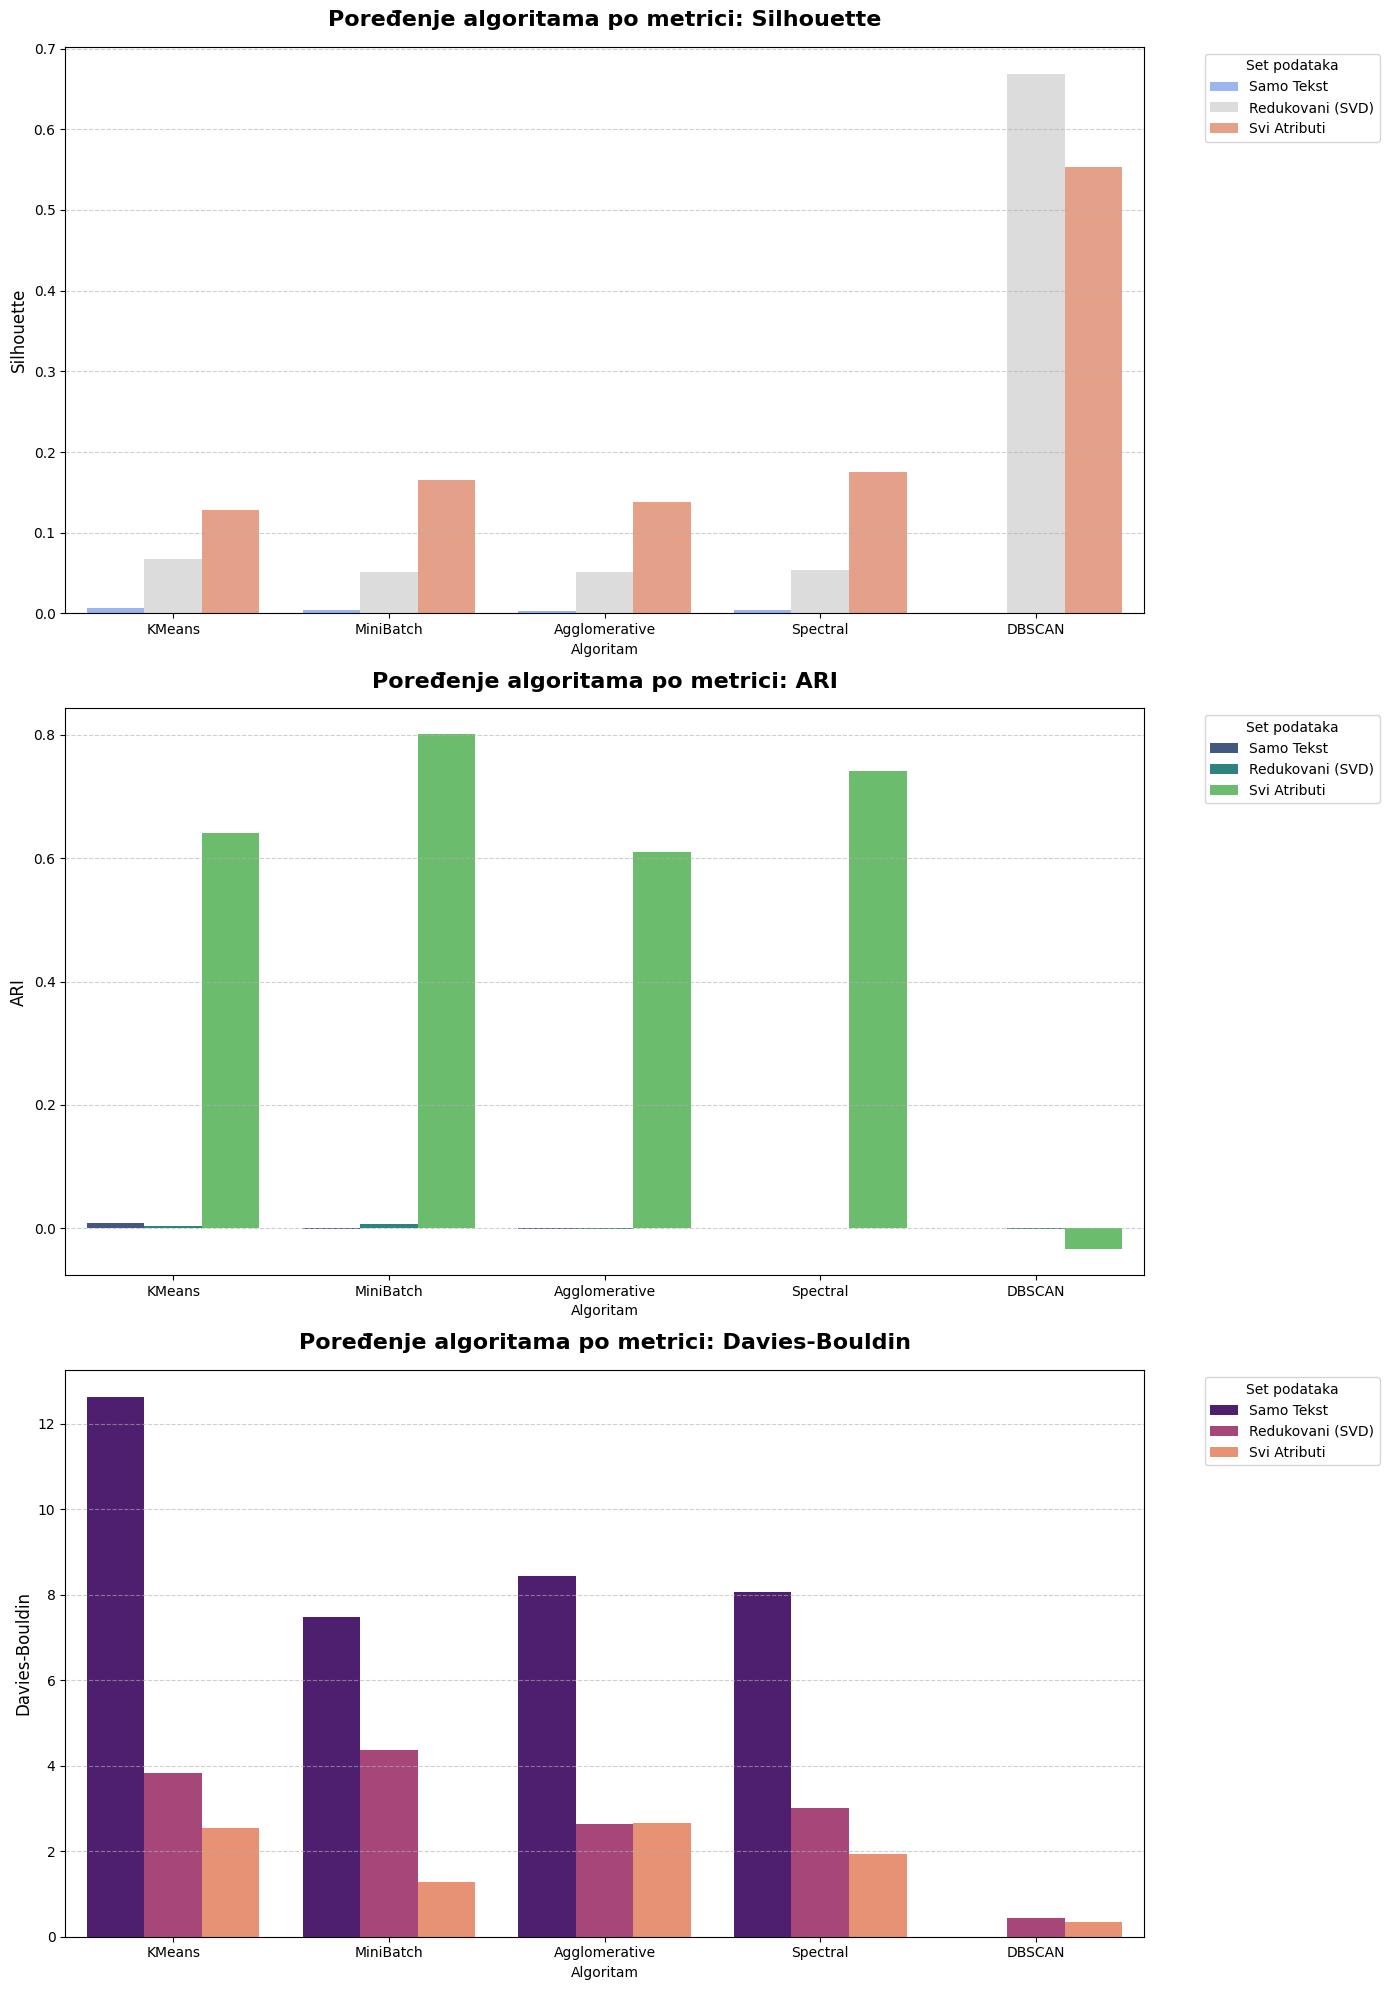

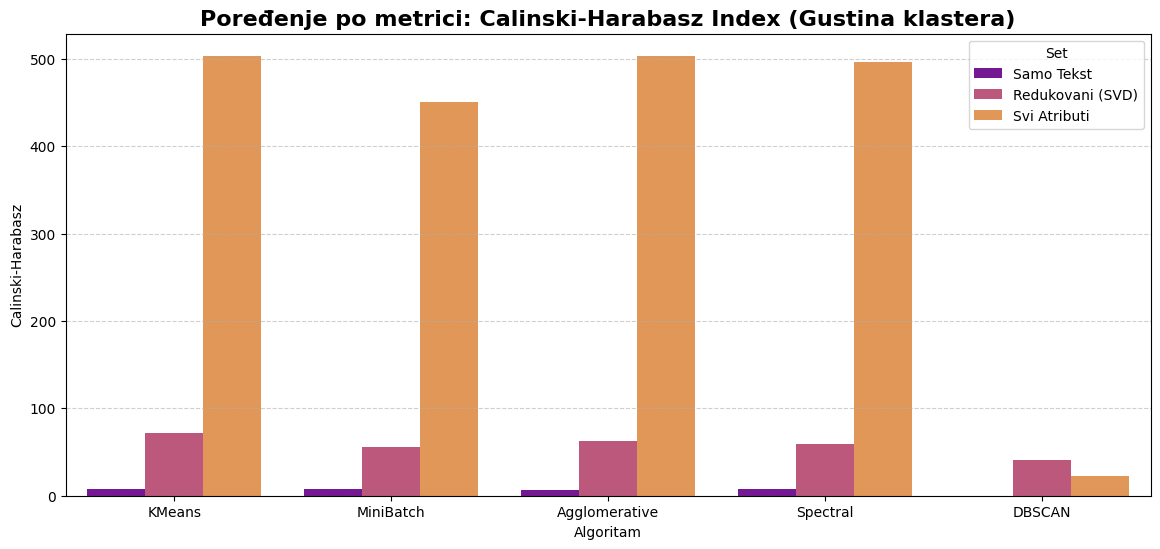

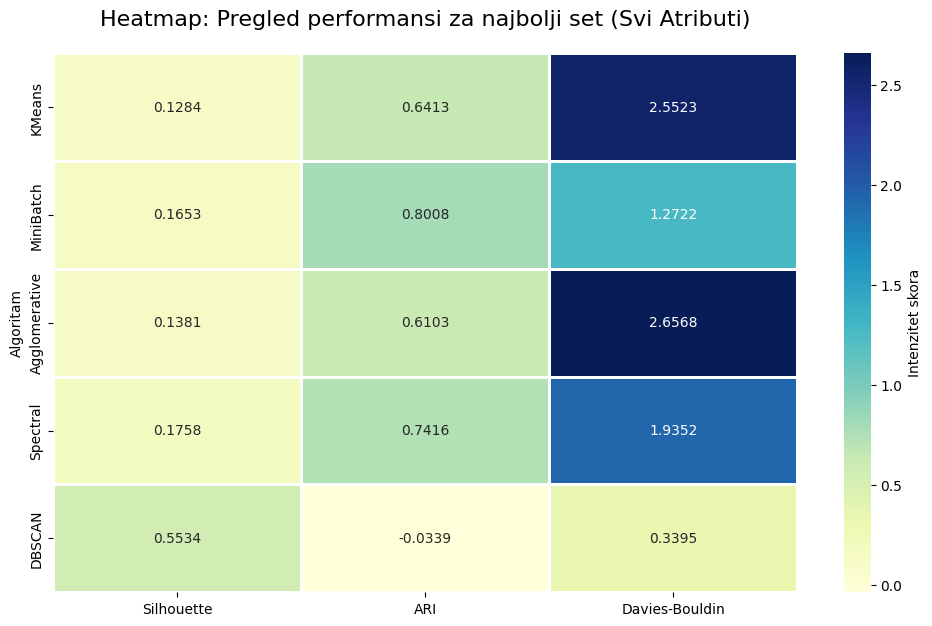


************************************************************
FINALNI IZVEŠTAJ
************************************************************
 NAJBOLJI SILHOUETTE (Struktura): DBSCAN na setu 'Redukovani (SVD)' -> 0.6687
 NAJBOLJI ARI (Sentiment): MiniBatch na setu 'Svi Atributi' -> 0.8008
 Najbolji DB INDEX (Razdvojenost): DBSCAN na setu 'Svi Atributi' -> 0.3395
************************************************************


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Isključujemo upozorenja da bi ispis bio čist
warnings.simplefilter(action='ignore', category=FutureWarning)

try:
    # 1. UCITAVANJE SVA TRI IZVORA
    df_text = pd.read_csv("rezultati_text.csv")
    df_svd = pd.read_csv("rezultati_svd.csv")
    df_all = pd.read_csv("rezultati_all.csv")

    df_text['Set'] = 'Samo Tekst'
    df_svd['Set'] = 'Redukovani (SVD)'
    df_all['Set'] = 'Svi Atributi'

    # Spajanje u Master DataFrame
    df_master = pd.concat([df_text, df_svd, df_all], ignore_index=True)

    # 2. KOMPLETNA UPOREDNA TABELA ZA SVE METRIKE
    print("\n" + "="*85)
    print("DETALJAN UPOREDNI PREGLED SVIH METRIKA KROZ SVE SETOVE PODATAKA")
    print("="*85)
    
    # Pivot tabela koja prikazuje sve metrike (Silhouette, ARI, DB, CH)
    finalna_tabela = df_master.pivot_table(index=['Set', 'Algoritam'])
    # Ređamo kolone da ARI i Silhouette budu prvi
    finalna_tabela = finalna_tabela[['Silhouette', 'ARI', 'Davies-Bouldin', 'Calinski-Harabasz']]
    
    # Ispisujemo celu tabelu (ovo kopiraj u Word)
    pd.set_option('display.max_rows', None)
    print(finalna_tabela.round(4))
    print("="*85)

    # 3. POSEBNI GRAFIKONI ZA SVAKU METRIKU
    # Reorganizujemo podatke za crtanje (Melt)
    df_melted = df_master.melt(id_vars=['Algoritam', 'Set'], 
                                value_vars=['Silhouette', 'ARI', 'Davies-Bouldin'],
                                var_name='Metrika', value_name='Vrednost')

    # Kreiramo 3 velika grafikona (jedan ispod drugog)
    fig, axes = plt.subplots(3, 1, figsize=(14, 20))

    metrike = ['Silhouette', 'ARI', 'Davies-Bouldin']
    palete = ['coolwarm', 'viridis', 'magma']

    for i, metrika in enumerate(metrike):
        sns.barplot(data=df_melted[df_melted['Metrika'] == metrika], 
                    x='Algoritam', y='Vrednost', hue='Set', 
                    ax=axes[i], palette=palete[i])
        axes[i].set_title(f'Poređenje algoritama po metrici: {metrika}', fontsize=16, fontweight='bold', pad=15)
        axes[i].set_ylabel(metrika, fontsize=12)
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)
        axes[i].legend(title='Set podataka', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # 4. POSEBAN GRAFIK ZA CALINSKI-HARABASZ (Zbog velikih vrednosti)
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_master, x='Algoritam', y='Calinski-Harabasz', hue='Set', palette='plasma')
    plt.title('Poređenje po metrici: Calinski-Harabasz Index (Gustina klastera)', fontsize=16, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    # 5. HEATMAPA ZA "SVI ATRIBUTI" (Tvoj najbolji fajl)
    plt.figure(figsize=(12, 7))
    metrics_all = df_all.set_index('Algoritam')[['Silhouette', 'ARI', 'Davies-Bouldin']]
    sns.heatmap(metrics_all, annot=True, cmap="YlGnBu", fmt=".4f", linewidths=1, cbar_kws={'label': 'Intenzitet skora'})
    plt.title('Heatmap: Pregled performansi za najbolji set (Svi Atributi)', fontsize=16, pad=20)
    plt.show()

    # 6. ZAKLJUČAK I NAJBOLJI REZULTATI
    best_sil = df_master.loc[df_master['Silhouette'].idxmax()]
    best_ari = df_master.loc[df_master['ARI'].idxmax()]
    df_db_valid = df_master[df_master['Davies-Bouldin'] > 0]

    # Ako imamo validne rezultate, uzmi najmanji
    if not df_db_valid.empty:
        best_db = df_db_valid.loc[df_db_valid['Davies-Bouldin'].idxmin()]
        db_ispis = f"{best_db['Algoritam']} na setu '{best_db['Set']}' -> {best_db['Davies-Bouldin']:.4f}"
    else:
        db_ispis = "Nema validnih rezultata"
    print("\n" + "*"*60)
    print("FINALNI IZVEŠTAJ")
    print("*"*60)
    print(f" NAJBOLJI SILHOUETTE (Struktura): {best_sil['Algoritam']} na setu '{best_sil['Set']}' -> {best_sil['Silhouette']:.4f}")
    print(f" NAJBOLJI ARI (Sentiment): {best_ari['Algoritam']} na setu '{best_ari['Set']}' -> {best_ari['ARI']:.4f}")
    print(f" Najbolji DB INDEX (Razdvojenost): {best_db['Algoritam']} na setu '{best_db['Set']}' -> {best_db['Davies-Bouldin']:.4f}")
    print("*"*60)

except Exception as e:
    print(f"Greška: {e}. Proveri da li su nazivi rezultata .csv ispravni!")